# Codes de Surface et Décodage MWPM

Code de surface rotatif (rotated surface code) de distance $d$:

- Qubits de données: $d^2$
- Qubits auxiliaires (syndrome): $d^2 - 1$
- Seuil d'erreur: $p_{\text{th}} \approx 0.01$

In [1]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt

### Construction du code de surface rotatif (Stim)

Circuit de stabilisation pour un cycle de détection d'erreurs.

Générateurs de stabilisateurs:
- Plaquettes $X$: $\prod_{i \in \partial p} X_i$
- Plaquettes $Z$: $\prod_{i \in \partial p} Z_i$

In [2]:
def make_rotated_surface_code_circuit(d, rounds, p):
    circuit = stim.Circuit()

    data = [[i * d + j for j in range(d)] for i in range(d)]
    data_qubits = [q for row in data for q in row]

    for q in data_qubits:
        circuit.append('DEPOLARIZE1', [q], p)

    meas_idx = d * d
    for _ in range(rounds):
        for i in range(d - 1):
            for j in range(d - 1):
                if (i + j) % 2 == 0:
                    circuit.append('R', [meas_idx])
                    circuit.append('CNOT', [data[i][j], meas_idx])
                    circuit.append('CNOT', [data[i][j+1], meas_idx])
                    circuit.append('CNOT', [data[i+1][j], meas_idx])
                    circuit.append('CNOT', [data[i+1][j+1], meas_idx])
                    circuit.append('MR', [meas_idx])
                else:
                    circuit.append('R', [meas_idx])
                    circuit.append('CNOT', [meas_idx, data[i][j]])
                    circuit.append('CNOT', [meas_idx, data[i][j+1]])
                    circuit.append('CNOT', [meas_idx, data[i+1][j]])
                    circuit.append('CNOT', [meas_idx, data[i+1][j+1]])
                    circuit.append('MR', [meas_idx])
                meas_idx += 1

    for q in data_qubits:
        circuit.append('M', [q])

    return circuit

In [3]:
# Test: circuit de distance 3
d = 3
circ = make_rotated_surface_code_circuit(d, rounds=1, p=0.001)
print('Circuit code surface (distance 3, 1 round):')
print(circ)

Circuit code surface (distance 3, 1 round):
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8
R 9
CX 0 9 1 9 3 9 4 9
MR 9
R 10
CX 10 1 10 2 10 4 10 5
MR 10
R 11
CX 11 3 11 4 11 6 11 7
MR 11
R 12
CX 4 12 5 12 7 12 8 12
MR 12
M 0 1 2 3 4 5 6 7 8


### Extraction du syndrome et décodage MWPM

Le syndrome est extrait via les mesures des plaquettes.

MWPM (Minimum Weight Perfect Matching) appaire les défauts de syndrome pour trouver l'erreur la plus probable.

In [4]:
def simulate_and_decode(d, p, n_shots=5000):
    circuit = make_rotated_surface_code_circuit(d, rounds=d, p=p)
    model = circuit.detector_error_model()
    sampler = circuit.compile_detector_sampler()
    dets, obs = sampler.sample(n_shots, separate_observables=True)

    matching = pymatching.Matching.from_detector_error_model(model)
    predictions = matching.decode_batch(dets)

    errors = np.any(predictions != obs, axis=1)
    return np.mean(errors)

In [5]:
# Test de décodage
p_test = 0.005
err_rate = simulate_and_decode(3, p_test, 2000)
print(f'd=3, p={p_test}: erreur logique = {err_rate:.4f}')

d=3, p=0.005: erreur logique = 0.0000


### Calcul du seuil d'erreur

Le seuil $p_{\text{th}}$ est le point d'intersection des courbes $P_{\text{erreur}}(p)$ pour différentes distances $d$:

$$\lim_{d\to\infty} P_{\text{err}}(p) = \begin{cases} 0 & p < p_{\text{th}} \\ 1 & p > p_{\text{th}} \end{cases}$$

In [6]:
distances = [3, 5, 7]
p_vals = np.linspace(0.003, 0.02, 8)
results = {d: [] for d in distances}

for d in distances:
    for p in p_vals:
        err = simulate_and_decode(d, p, 2000)
        results[d].append(err)
        print(f'd={d}, p={p:.4f}: err={err:.4f}')

d=3, p=0.0030: err=0.0000


d=3, p=0.0054: err=0.0000


d=3, p=0.0079: err=0.0000


d=3, p=0.0103: err=0.0000


d=3, p=0.0127: err=0.0000
d=3, p=0.0151: err=0.0000


...

d=7, p=0.0103: err=0.0000


d=7, p=0.0127: err=0.0000


d=7, p=0.0151: err=0.0000


d=7, p=0.0176: err=0.0000


d=7, p=0.0200: err=0.0000


/tmp/ipykernel_34979/33727235.py:11: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


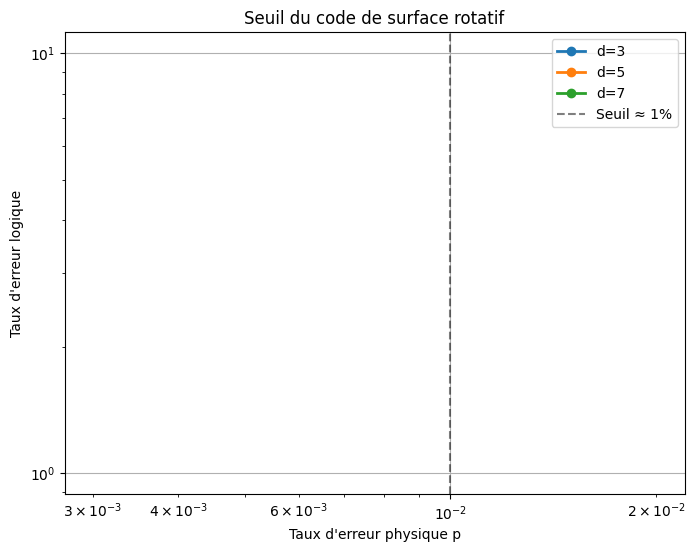

In [7]:
plt.figure(figsize=(8, 6))
for d in distances:
    plt.plot(p_vals, results[d], 'o-', label=f'd={d}', linewidth=2)
plt.axvline(0.01, color='k', linestyle='--', alpha=0.5, label='Seuil ≈ 1%')
plt.xlabel('Taux d\'erreur physique p')
plt.ylabel('Taux d\'erreur logique')
plt.title('Seuil du code de surface rotatif')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.show()

## Questions

**Q1.** Faire varier la distance $d$ de 3 à 9 et le nombre de rounds pour atteindre $d$ rounds. Tracer le taux d'erreur logique en fonction de $p$ pour chaque distance. Identifier graphiquement le seuil $p_{\text{th}}$.

**Q2.** Ajouter du bruit sur les mesures (erreur de mesure $p_{\text{meas}} = 0.01$) dans le circuit Stim. Comparer le seuil obtenu avec celui du cas sans erreur de mesure.

d=3, p=0.00316: err=0.00000
d=3, p=0.00408: err=0.00000


d=3, p=0.00527: err=0.00000
d=3, p=0.00681: err=0.00000


d=3, p=0.00880: err=0.00000
d=3, p=0.01136: err=0.00000


d=3, p=0.01468: err=0.00000
d=3, p=0.01896: err=0.00000
d=3, p=0.02448: err=0.00000


d=3, p=0.03162: err=0.00000
d=5, p=0.00316: err=0.00000


...

d=9, p=0.01468: err=0.00000


d=9, p=0.01896: err=0.00000


d=9, p=0.02448: err=0.00000


d=9, p=0.03162: err=0.00000


/tmp/ipykernel_34979/2352869317.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


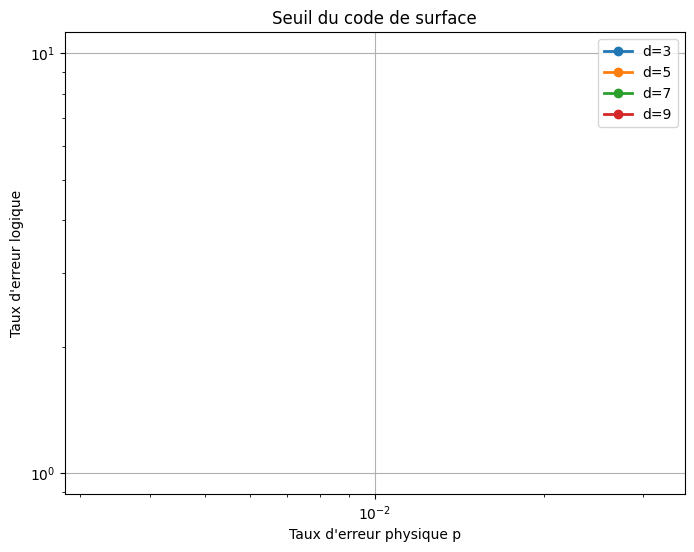

In [8]:
# Q1: Seuil avec plus de distances
distances_ext = [3, 5, 7, 9]
p_range = np.logspace(-2.5, -1.5, 10)
results_ext = {d: [] for d in distances_ext}

for d in distances_ext:
    for p in p_range:
        err = simulate_and_decode(d, p, 1000)
        results_ext[d].append(err)
        print(f'd={d}, p={p:.5f}: err={err:.5f}')

plt.figure(figsize=(8, 6))
for d in distances_ext:
    plt.plot(p_range, results_ext[d], 'o-', label=f'd={d}', linewidth=2)
plt.xlabel('Taux d\'erreur physique p')
plt.ylabel('Taux d\'erreur logique')
plt.title('Seuil du code de surface')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()